# SIFT vs No-SIFT Pipeline Comparison

This notebook compares the performance and behavior of the tracking pipeline with and without SIFT feature enhancement.

## Comparison Overview

- **Left/First**: Standard pipeline (background subtraction only)
- **Right/Second**: SIFT-enhanced pipeline (background subtraction + SIFT feature validation)

## Key Differences

1. **Detection Quality**: SIFT helps validate detections by checking for feature-rich regions
2. **False Positive Reduction**: Regions without distinctive features are filtered out
3. **Tracking Stability**: Feature-validated detections lead to more stable tracks
4. **Computational Cost**: SIFT adds processing time but improves accuracy


In [1]:
import cv2
import numpy as np
import glob
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
import time
import sys
sys.path.append('..')

from sot import (
    SOT, Pipeline, PipelineStep,
    DetectionStep, TrackingStep, VisualizationStep,
    FramePreprocessingStep,
    SIFTFeatureStep, SIFTMatchingStep, 
    SIFTEnhancedDetectionStep, SIFTVisualizationStep
)
from detector import ObjectDetector
from tracker import ObjectTracker

## 1. Load Video Frames

We'll use one of the bee tracking videos for comparison.


Video: bees_short
Total frames: 840
Frame size: (1156, 2052, 3)


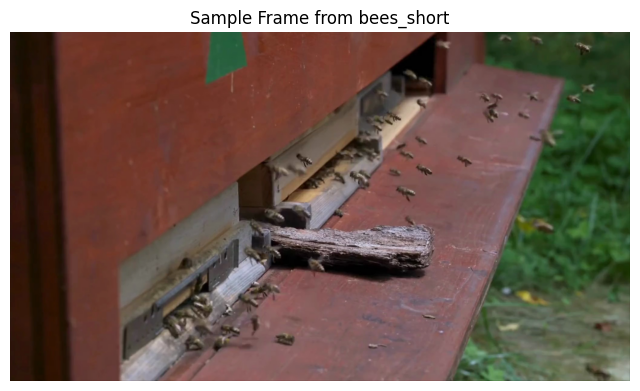

In [2]:
video_name = 'bees_short'  # Change to: bees_short, bees1_longer, bees2_longer, city_longer, videoplayback

frame_pattern = f"../data/images/{video_name}/images/*.jpg"
frame_files = sorted(glob.glob(frame_pattern))

print(f"Video: {video_name}")
print(f"Total frames: {len(frame_files)}")

if len(frame_files) > 0:
    sample_frame = cv2.imread(frame_files[0])
    print(f"Frame size: {sample_frame.shape}")
    
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(sample_frame, cv2.COLOR_BGR2RGB))
    plt.title(f"Sample Frame from {video_name}")
    plt.axis('off')
    plt.show()
else:
    print("No frames found! Check the path.")


## 2. Configure Pipelines

### Pipeline 1: Standard Detection (No SIFT)


In [3]:
pipeline_standard = Pipeline()

pipeline_standard.add_step(FramePreprocessingStep(blur_ksize=5))

detector_standard = ObjectDetector(
    history=500,
    dist_threshold=800,
    min_area=30,
    max_area=100000,
    erode_size=(3, 3),
    dilate_size=(8, 8)
)
pipeline_standard.add_step(DetectionStep(detector=detector_standard))

tracker_standard = ObjectTracker(
    max_distance=30.0,
    min_hits=3,
    max_age=30
)
pipeline_standard.add_step(TrackingStep(tracker=tracker_standard))

pipeline_standard.add_step(VisualizationStep(
    draw_detections=True,
    draw_tracks=True,
    draw_trajectories=True,
    draw_ids=True
))

print("Standard pipeline configured")
print(f"  Steps: {pipeline_standard.list_steps()}")


Standard pipeline configured
  Steps: ['preprocessing', 'detection', 'tracking', 'visualization']


### Pipeline 2: SIFT-Enhanced Detection


In [4]:
pipeline_sift = Pipeline()

pipeline_sift.add_step(FramePreprocessingStep(blur_ksize=5))

pipeline_sift.add_step(SIFTFeatureStep(
    nfeatures=500,
    contrastThreshold=0.04,
    edgeThreshold=10
))

pipeline_sift.add_step(SIFTMatchingStep(
    ratio_threshold=0.75,
    min_match_count=4
))

detector_sift = ObjectDetector(
    history=500,
    dist_threshold=800,
    min_area=30,
    max_area=100000,
    erode_size=(3, 3),
    dilate_size=(8, 8)
)
pipeline_sift.add_step(SIFTEnhancedDetectionStep(
    detector=detector_sift,
    min_features_in_detection=2,
    feature_density_threshold=0.001
))

tracker_sift = ObjectTracker(
    max_distance=30.0,
    min_hits=3,
    max_age=30
)
pipeline_sift.add_step(TrackingStep(tracker=tracker_sift))

pipeline_sift.add_step(SIFTVisualizationStep(
    draw_keypoints=True,
    draw_matches=False,
    draw_detections=True,
    max_keypoints=100
))

pipeline_sift.add_step(VisualizationStep(
    draw_detections=False,
    draw_tracks=True,
    draw_trajectories=True,
    draw_ids=True
))

print("SIFT-enhanced pipeline configured")
print(f"  Steps: {pipeline_sift.list_steps()}")


SIFT-enhanced pipeline configured
  Steps: ['preprocessing', 'sift_features', 'sift_matching', 'sift_enhanced_detection', 'tracking', 'sift_visualization', 'visualization']


## 3. Process Frames with Both Pipelines

We'll process the same frames through both pipelines and collect metrics.


In [5]:
max_frames = 100  # Set to None to process all frames
frames_to_process = frame_files[:max_frames] if max_frames else frame_files

print(f"Processing {len(frames_to_process)} frames...\n")

results_standard = []
results_sift = []
vis_frames_standard = []
vis_frames_sift = []

metrics = {
    'standard': {
        'detections': [],
        'tracks': [],
        'processing_time': []
    },
    'sift': {
        'detections': [],
        'tracks': [],
        'sift_features': [],
        'sift_matches': [],
        'processing_time': []
    }
}

for i, frame_path in enumerate(frames_to_process):
    frame = cv2.imread(frame_path)
    
    if frame is None:
        continue
    
    start_time = time.time()
    context_std = pipeline_standard.process(frame.copy(), {'frame_number': i})
    time_std = time.time() - start_time
    
    results_standard.append(context_std)
    vis_frames_standard.append(context_std.get('visualization', frame))
    metrics['standard']['detections'].append(context_std.get('num_detections', 0))
    metrics['standard']['tracks'].append(context_std.get('num_confirmed', 0))
    metrics['standard']['processing_time'].append(time_std)
    
    start_time = time.time()
    context_sift = pipeline_sift.process(frame.copy(), {'frame_number': i})
    time_sift = time.time() - start_time
    
    results_sift.append(context_sift)
    vis_frame_sift = context_sift.get('visualization', 
                                      context_sift.get('sift_visualization', frame))
    vis_frames_sift.append(vis_frame_sift)
    metrics['sift']['detections'].append(context_sift.get('num_detections', 0))
    metrics['sift']['tracks'].append(context_sift.get('num_confirmed', 0))
    metrics['sift']['sift_features'].append(context_sift.get('num_sift_features', 0))
    metrics['sift']['sift_matches'].append(context_sift.get('num_sift_matches', 0))
    metrics['sift']['processing_time'].append(time_sift)
    
    if (i + 1) % 20 == 0:
        print(f"Processed {i+1}/{len(frames_to_process)} frames")

print("Processing complete!")


Processing 100 frames...

Processed 20/100 frames
Processed 40/100 frames
Processed 60/100 frames
Processed 80/100 frames
Processed 100/100 frames
Processing complete!


## 4. Compare Metrics

Let's visualize the differences between the two approaches.


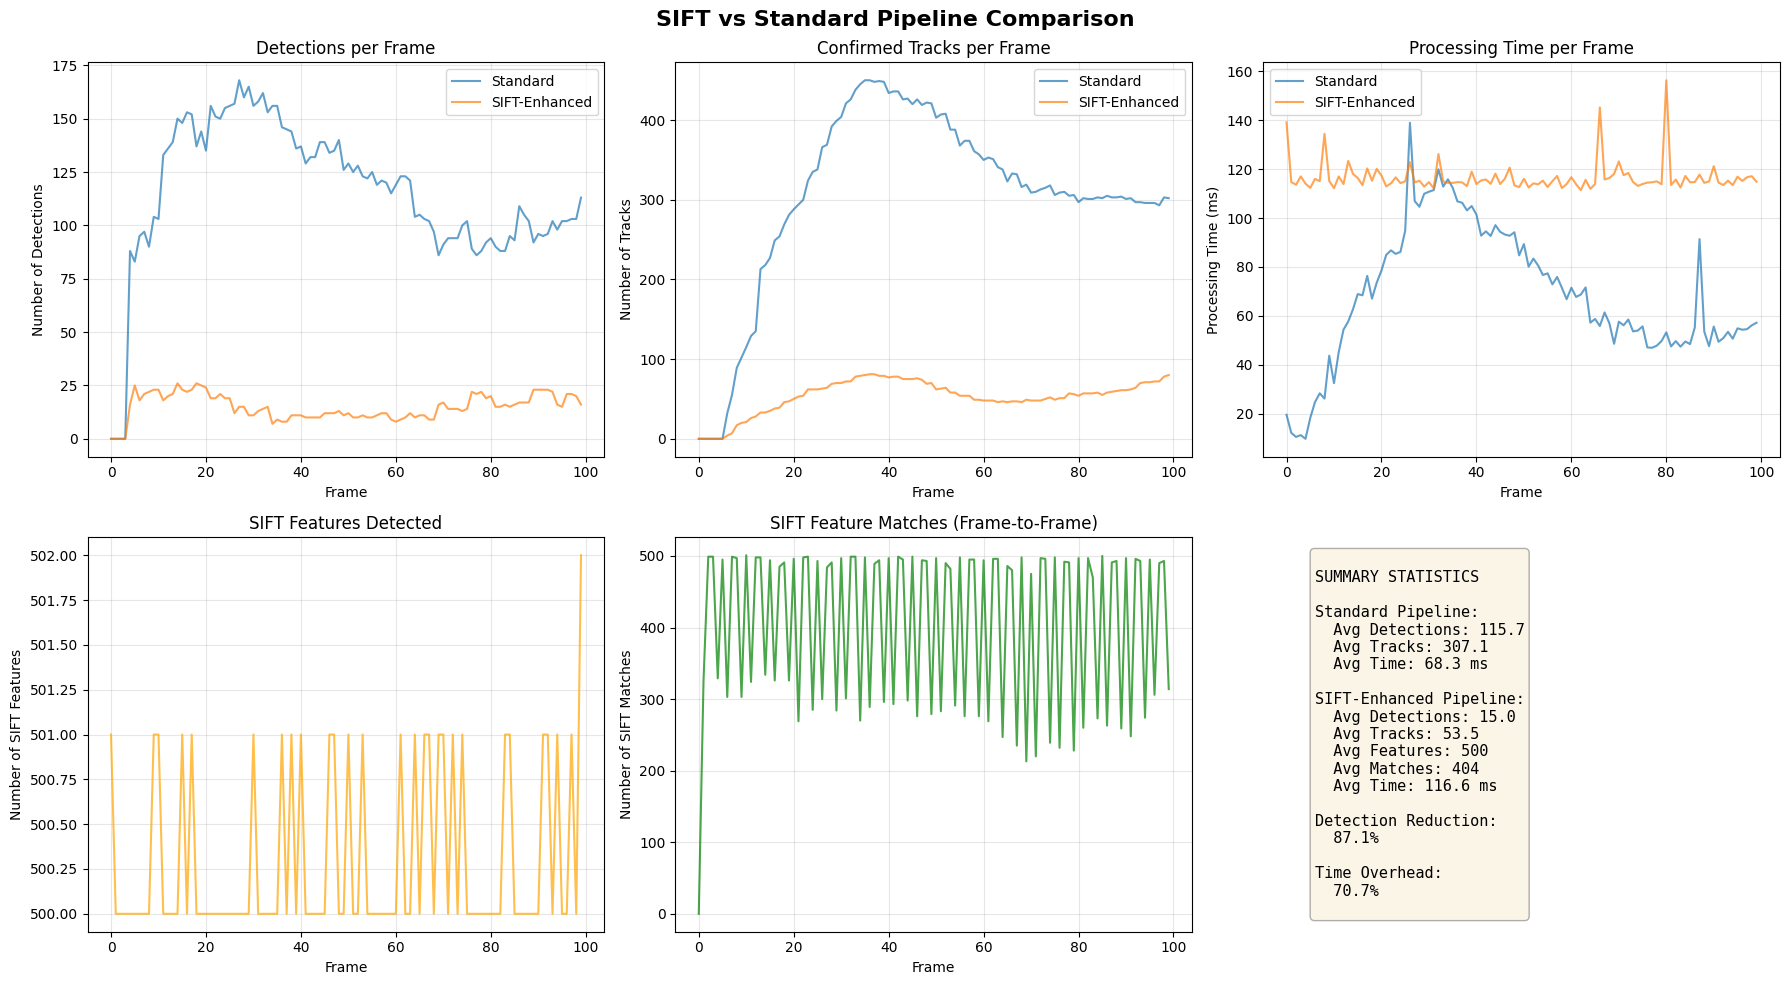

Metrics comparison complete!


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('SIFT vs Standard Pipeline Comparison', fontsize=16, fontweight='bold')

frames = range(len(frames_to_process))

# Number of detections
axes[0, 0].plot(frames, metrics['standard']['detections'], label='Standard', alpha=0.7)
axes[0, 0].plot(frames, metrics['sift']['detections'], label='SIFT-Enhanced', alpha=0.7)
axes[0, 0].set_xlabel('Frame')
axes[0, 0].set_ylabel('Number of Detections')
axes[0, 0].set_title('Detections per Frame')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Number of confirmed tracks
axes[0, 1].plot(frames, metrics['standard']['tracks'], label='Standard', alpha=0.7)
axes[0, 1].plot(frames, metrics['sift']['tracks'], label='SIFT-Enhanced', alpha=0.7)
axes[0, 1].set_xlabel('Frame')
axes[0, 1].set_ylabel('Number of Tracks')
axes[0, 1].set_title('Confirmed Tracks per Frame')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Processing time
axes[0, 2].plot(frames, np.array(metrics['standard']['processing_time']) * 1000, 
                label='Standard', alpha=0.7)
axes[0, 2].plot(frames, np.array(metrics['sift']['processing_time']) * 1000, 
                label='SIFT-Enhanced', alpha=0.7)
axes[0, 2].set_xlabel('Frame')
axes[0, 2].set_ylabel('Processing Time (ms)')
axes[0, 2].set_title('Processing Time per Frame')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# SIFT features detected
axes[1, 0].plot(frames, metrics['sift']['sift_features'], color='orange', alpha=0.7)
axes[1, 0].set_xlabel('Frame')
axes[1, 0].set_ylabel('Number of SIFT Features')
axes[1, 0].set_title('SIFT Features Detected')
axes[1, 0].grid(True, alpha=0.3)

# SIFT matches
axes[1, 1].plot(frames, metrics['sift']['sift_matches'], color='green', alpha=0.7)
axes[1, 1].set_xlabel('Frame')
axes[1, 1].set_ylabel('Number of SIFT Matches')
axes[1, 1].set_title('SIFT Feature Matches (Frame-to-Frame)')
axes[1, 1].grid(True, alpha=0.3)

# Summary statistics
axes[1, 2].axis('off')
summary_text = f"""
SUMMARY STATISTICS

Standard Pipeline:
  Avg Detections: {np.mean(metrics['standard']['detections']):.1f}
  Avg Tracks: {np.mean(metrics['standard']['tracks']):.1f}
  Avg Time: {np.mean(metrics['standard']['processing_time'])*1000:.1f} ms

SIFT-Enhanced Pipeline:
  Avg Detections: {np.mean(metrics['sift']['detections']):.1f}
  Avg Tracks: {np.mean(metrics['sift']['tracks']):.1f}
  Avg Features: {np.mean(metrics['sift']['sift_features']):.0f}
  Avg Matches: {np.mean(metrics['sift']['sift_matches']):.0f}
  Avg Time: {np.mean(metrics['sift']['processing_time'])*1000:.1f} ms

Detection Reduction:
  {(1 - np.mean(metrics['sift']['detections'])/max(np.mean(metrics['standard']['detections']), 1))*100:.1f}%

Time Overhead:
  {(np.mean(metrics['sift']['processing_time'])/np.mean(metrics['standard']['processing_time']) - 1)*100:.1f}%
"""
axes[1, 2].text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
                verticalalignment='center', bbox=dict(boxstyle='round', 
                facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

print("Metrics comparison complete!")


## 5. Side-by-Side Frame Comparison

View frames from both pipelines side by side.


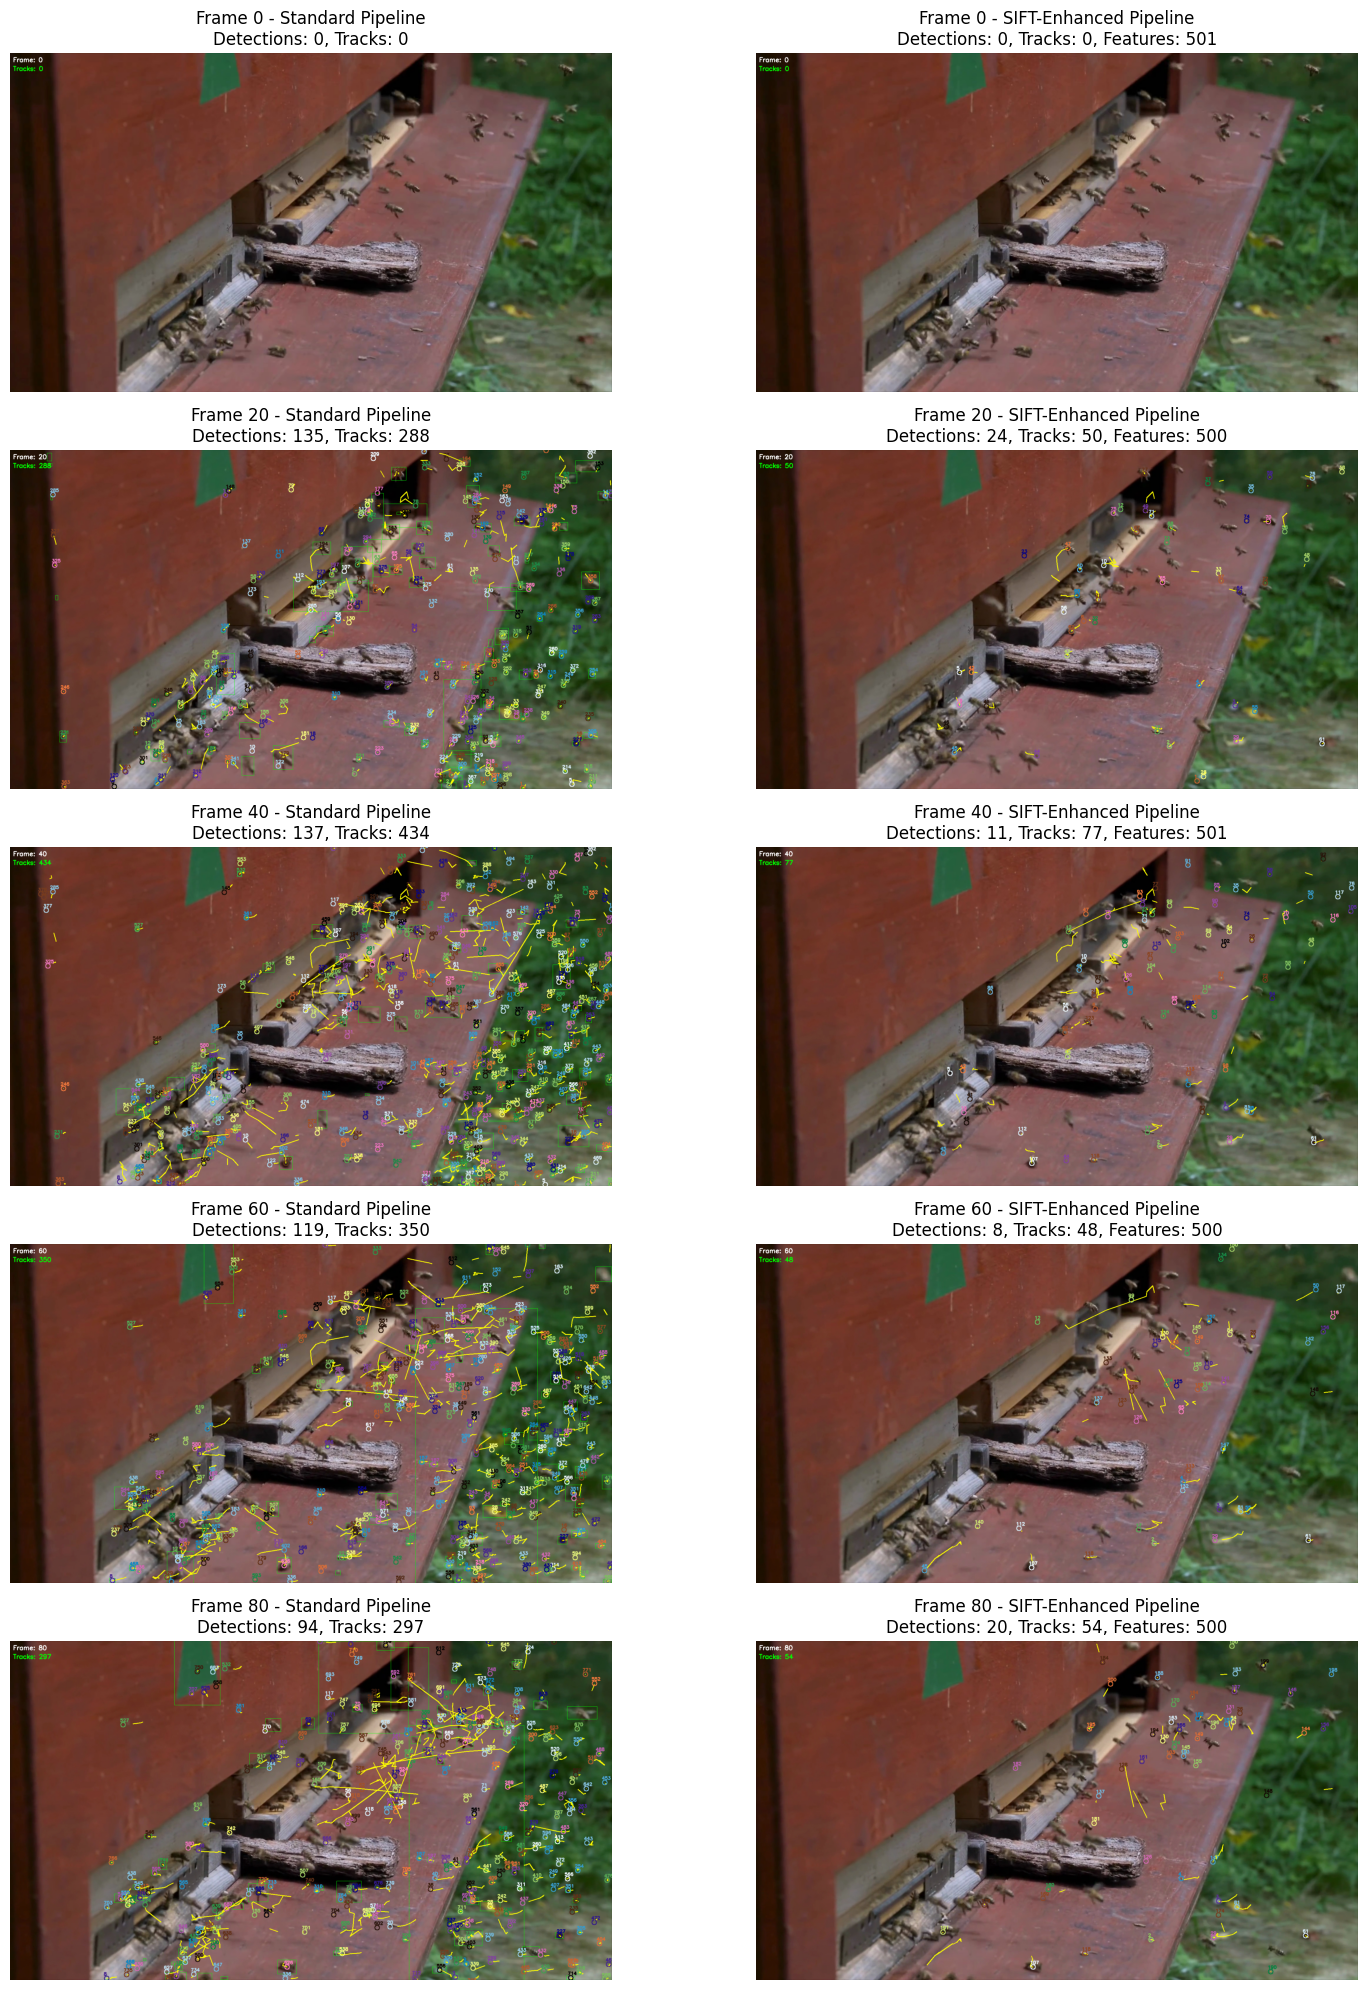

Side-by-side comparison complete!


In [7]:
frame_indices = [0, 20, 40, 60, 80]
frame_indices = [i for i in frame_indices if i < len(vis_frames_standard)]

fig, axes = plt.subplots(len(frame_indices), 2, figsize=(16, 4*len(frame_indices)))
if len(frame_indices) == 1:
    axes = axes.reshape(1, -1)

for idx, frame_idx in enumerate(frame_indices):
    frame_std = cv2.cvtColor(vis_frames_standard[frame_idx], cv2.COLOR_BGR2RGB)
    axes[idx, 0].imshow(frame_std)
    axes[idx, 0].set_title(f'Frame {frame_idx} - Standard Pipeline\n'
                           f'Detections: {metrics["standard"]["detections"][frame_idx]}, '
                           f'Tracks: {metrics["standard"]["tracks"][frame_idx]}')
    axes[idx, 0].axis('off')
    
    frame_sift = cv2.cvtColor(vis_frames_sift[frame_idx], cv2.COLOR_BGR2RGB)
    axes[idx, 1].imshow(frame_sift)
    axes[idx, 1].set_title(f'Frame {frame_idx} - SIFT-Enhanced Pipeline\n'
                          f'Detections: {metrics["sift"]["detections"][frame_idx]}, '
                          f'Tracks: {metrics["sift"]["tracks"][frame_idx]}, '
                          f'Features: {metrics["sift"]["sift_features"][frame_idx]}')
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()

print("Side-by-side comparison complete!")


## 6. Save Comparison Videos

Create output videos for both pipelines.


In [8]:
import os

output_dir = f"comparison_results/{video_name}"
os.makedirs(output_dir, exist_ok=True)

fps = 15
frame_size = vis_frames_standard[0].shape[:2][::-1]

video_path_std = os.path.join(output_dir, f"{video_name}_standard.mp4")
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
video_writer_std = cv2.VideoWriter(video_path_std, fourcc, fps, frame_size)

for frame in vis_frames_standard:
    video_writer_std.write(frame)
video_writer_std.release()
print(f"✓ Saved: {video_path_std}")

video_path_sift = os.path.join(output_dir, f"{video_name}_sift_enhanced.mp4")
video_writer_sift = cv2.VideoWriter(video_path_sift, fourcc, fps, frame_size)

for frame in vis_frames_sift:
    video_writer_sift.write(frame)
video_writer_sift.release()
print(f"✓ Saved: {video_path_sift}")

# Save side-by-side comparison video
video_path_combined = os.path.join(output_dir, f"{video_name}_comparison.mp4")
combined_size = (frame_size[0] * 2, frame_size[1])
video_writer_combined = cv2.VideoWriter(video_path_combined, fourcc, fps, combined_size)

for frame_std, frame_sift in zip(vis_frames_standard, vis_frames_sift):
    combined = np.hstack([frame_std, frame_sift])
    video_writer_combined.write(combined)
video_writer_combined.release()
print(f"✓ Saved: {video_path_combined}")

print(f"\nAll videos saved to: {output_dir}/")


✓ Saved: comparison_results/bees_short/bees_short_standard.mp4
✓ Saved: comparison_results/bees_short/bees_short_sift_enhanced.mp4
✓ Saved: comparison_results/bees_short/bees_short_comparison.mp4

All videos saved to: comparison_results/bees_short/


## 7. Detailed Analysis

Let's analyze specific scenarios where SIFT makes a difference.



FRAMES WITH MOST SIFT FILTERING:
════════════════════════════════════════════════════════════

Frame 29:
  Standard detections: 165
  SIFT detections: 11
  Filtered out: 154
  SIFT features: 500
  SIFT matches: 284

Frame 27:
  Standard detections: 168
  SIFT detections: 15
  Filtered out: 153
  SIFT features: 500
  SIFT matches: 484

Frame 34:
  Standard detections: 156
  SIFT detections: 7
  Filtered out: 149
  SIFT features: 500
  SIFT matches: 270

Frame 32:
  Standard detections: 162
  SIFT detections: 14
  Filtered out: 148
  SIFT features: 500
  SIFT matches: 499

Frame 35:
  Standard detections: 156
  SIFT detections: 9
  Filtered out: 147
  SIFT features: 500
  SIFT matches: 498


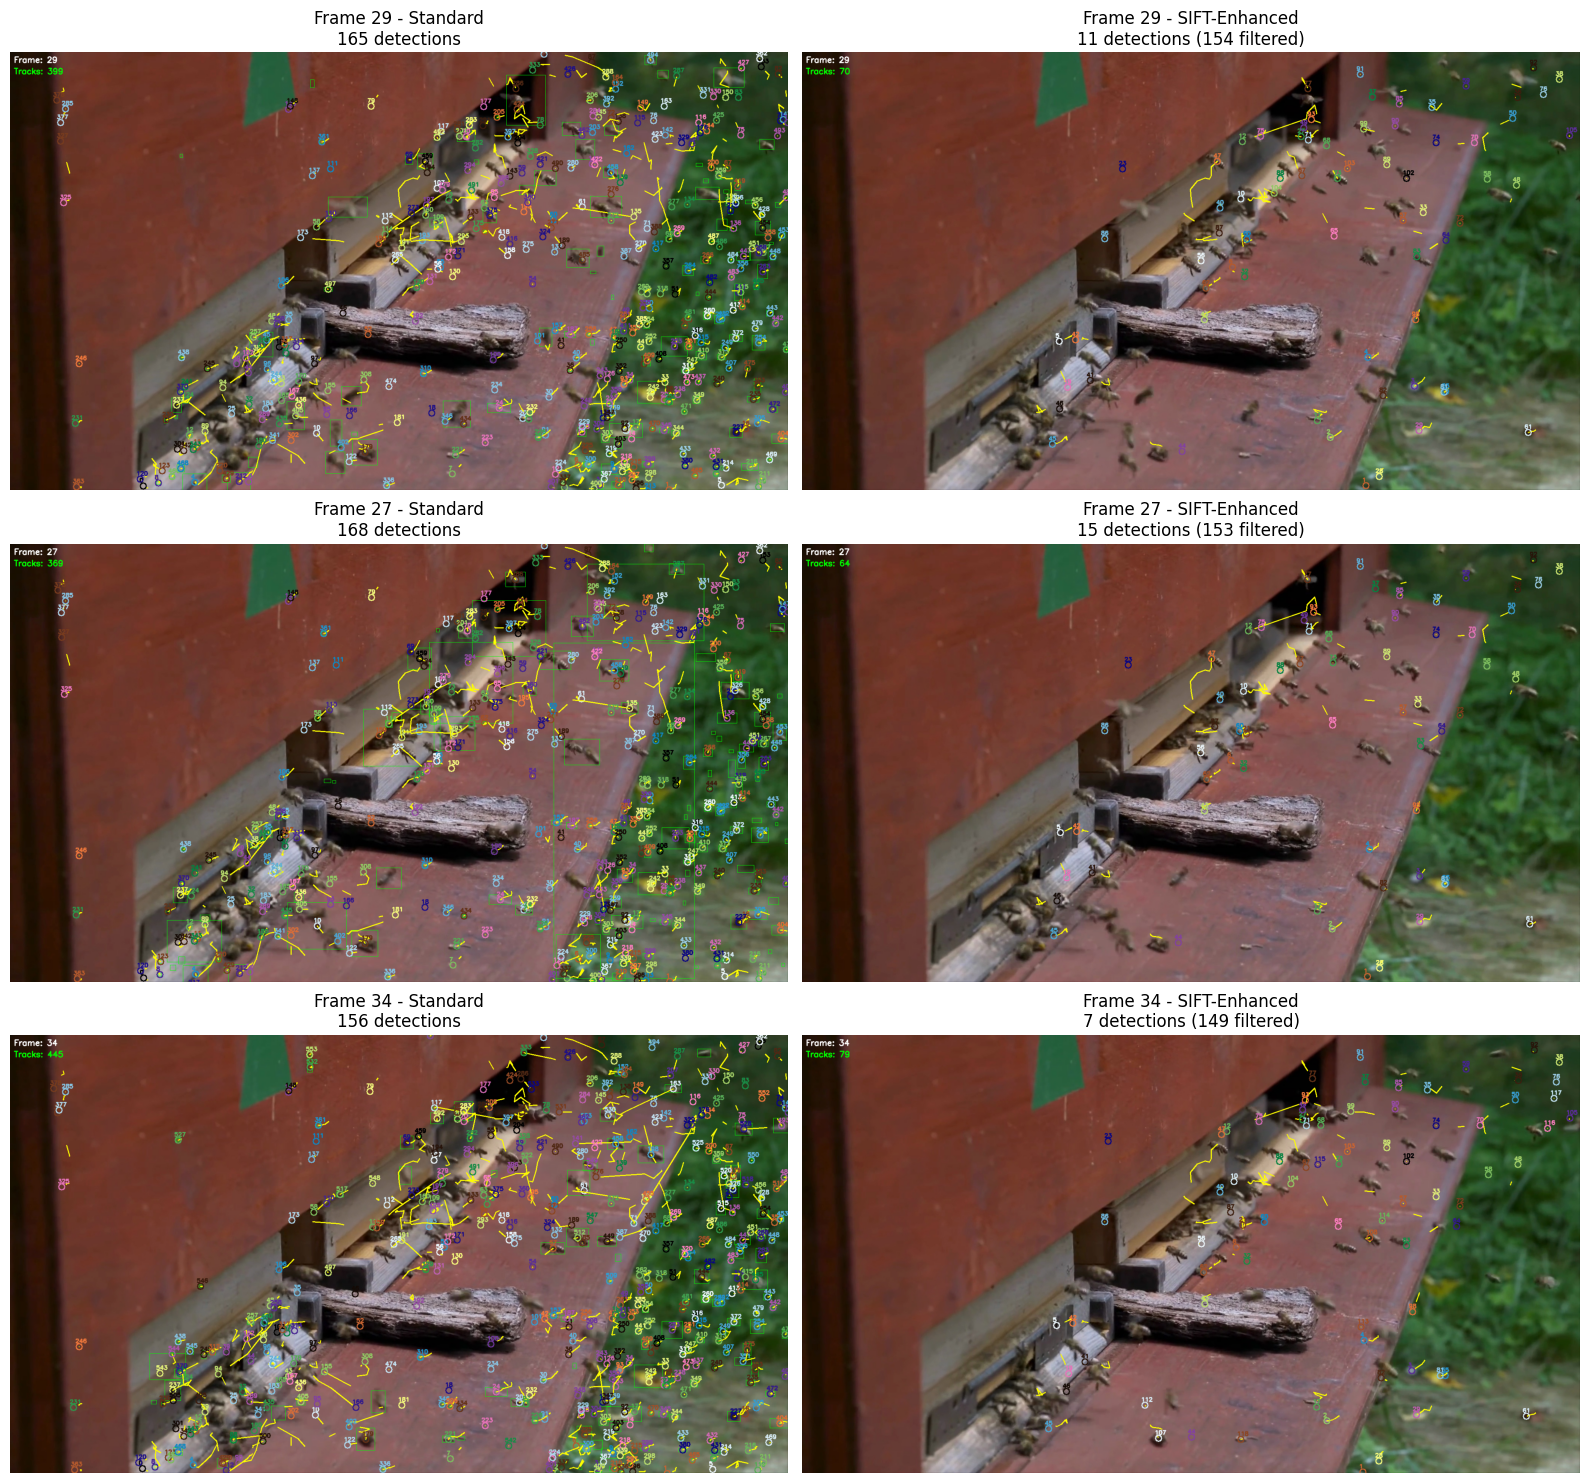

In [9]:
detection_diff = np.array(metrics['standard']['detections']) - np.array(metrics['sift']['detections'])
track_diff = np.array(metrics['standard']['tracks']) - np.array(metrics['sift']['tracks'])

max_filtering_frames = np.argsort(detection_diff)[-5:][::-1]

print("\nFRAMES WITH MOST SIFT FILTERING:")
print("═" * 60)
for frame_idx in max_filtering_frames:
    print(f"\nFrame {frame_idx}:")
    print(f"  Standard detections: {metrics['standard']['detections'][frame_idx]}")
    print(f"  SIFT detections: {metrics['sift']['detections'][frame_idx]}")
    print(f"  Filtered out: {detection_diff[frame_idx]}")
    print(f"  SIFT features: {metrics['sift']['sift_features'][frame_idx]}")
    print(f"  SIFT matches: {metrics['sift']['sift_matches'][frame_idx]}")

# Visualize these frames
if len(max_filtering_frames) > 0:
    fig, axes = plt.subplots(min(3, len(max_filtering_frames)), 2, 
                            figsize=(16, 5*min(3, len(max_filtering_frames))))
    if len(max_filtering_frames) == 1:
        axes = axes.reshape(1, -1)
    
    for idx, frame_idx in enumerate(max_filtering_frames[:3]):
        # Standard
        frame_std = cv2.cvtColor(vis_frames_standard[frame_idx], cv2.COLOR_BGR2RGB)
        axes[idx, 0].imshow(frame_std)
        axes[idx, 0].set_title(f'Frame {frame_idx} - Standard\n'
                               f'{metrics["standard"]["detections"][frame_idx]} detections')
        axes[idx, 0].axis('off')
        
        # SIFT
        frame_sift = cv2.cvtColor(vis_frames_sift[frame_idx], cv2.COLOR_BGR2RGB)
        axes[idx, 1].imshow(frame_sift)
        axes[idx, 1].set_title(f'Frame {frame_idx} - SIFT-Enhanced\n'
                              f'{metrics["sift"]["detections"][frame_idx]} detections '
                              f'({detection_diff[frame_idx]} filtered)')
        axes[idx, 1].axis('off')
    
    plt.tight_layout()
    plt.show()


## 8. Performance Summary

Overall comparison of both approaches.


In [10]:
print("\n" + "═" * 70)
print("FINAL PERFORMANCE COMPARISON")
print("═" * 70)

std_det = metrics['standard']['detections']
sift_det = metrics['sift']['detections']
std_tracks = metrics['standard']['tracks']
sift_tracks = metrics['sift']['tracks']
std_time = metrics['standard']['processing_time']
sift_time = metrics['sift']['processing_time']

print(f"\n📊 DETECTION METRICS:")
print(f"  Standard Pipeline:")
print(f"    Total Detections: {sum(std_det)}")
print(f"    Avg per Frame: {np.mean(std_det):.2f} ± {np.std(std_det):.2f}")
print(f"    Max Detections: {max(std_det)}")
print(f"\n  SIFT-Enhanced Pipeline:")
print(f"    Total Detections: {sum(sift_det)}")
print(f"    Avg per Frame: {np.mean(sift_det):.2f} ± {np.std(sift_det):.2f}")
print(f"    Max Detections: {max(sift_det)}")
print(f"\n  → Detection Reduction: {((sum(std_det) - sum(sift_det)) / max(sum(std_det), 1) * 100):.1f}%")

print(f"\n🎯 TRACKING METRICS:")
print(f"  Standard Pipeline:")
print(f"    Avg Tracks: {np.mean(std_tracks):.2f} ± {np.std(std_tracks):.2f}")
print(f"    Max Tracks: {max(std_tracks)}")
print(f"\n  SIFT-Enhanced Pipeline:")
print(f"    Avg Tracks: {np.mean(sift_tracks):.2f} ± {np.std(sift_tracks):.2f}")
print(f"    Max Tracks: {max(sift_tracks)}")

print(f"\n🔍 SIFT FEATURE METRICS:")
print(f"  Avg Features per Frame: {np.mean(metrics['sift']['sift_features']):.0f}")
print(f"  Avg Matches per Frame: {np.mean(metrics['sift']['sift_matches']):.0f}")
print(f"  Feature Detection Rate: {np.mean([1 if f > 0 else 0 for f in metrics['sift']['sift_features']]) * 100:.1f}%")

print(f"\n⚡ PERFORMANCE METRICS:")
print(f"  Standard Pipeline:")
print(f"    Avg Time: {np.mean(std_time)*1000:.2f} ms/frame")
print(f"    Total Time: {sum(std_time):.2f} seconds")
print(f"    FPS: {1/np.mean(std_time):.1f}")
print(f"\n  SIFT-Enhanced Pipeline:")
print(f"    Avg Time: {np.mean(sift_time)*1000:.2f} ms/frame")
print(f"    Total Time: {sum(sift_time):.2f} seconds")
print(f"    FPS: {1/np.mean(sift_time):.1f}")
print(f"\n  → Time Overhead: {((np.mean(sift_time) / np.mean(std_time) - 1) * 100):.1f}%")

print(f"\n💡 RECOMMENDATIONS:")
if np.mean(sift_det) < np.mean(std_det) * 0.8:
    print("  ✓ SIFT significantly reduces false positives")
if np.std(sift_tracks) < np.std(std_tracks):
    print("  ✓ SIFT provides more stable tracking")
if np.mean(sift_time) < np.mean(std_time) * 2:
    print("  ✓ SIFT overhead is acceptable for real-time applications")
else:
    print("  ⚠ SIFT adds significant computational cost")

print("\n" + "═" * 70)



══════════════════════════════════════════════════════════════════════
FINAL PERFORMANCE COMPARISON
══════════════════════════════════════════════════════════════════════

📊 DETECTION METRICS:
  Standard Pipeline:
    Total Detections: 11566
    Avg per Frame: 115.66 ± 33.58
    Max Detections: 168

  SIFT-Enhanced Pipeline:
    Total Detections: 1497
    Avg per Frame: 14.97 ± 5.90
    Max Detections: 26

  → Detection Reduction: 87.1%

🎯 TRACKING METRICS:
  Standard Pipeline:
    Avg Tracks: 307.08 ± 115.69
    Max Tracks: 450

  SIFT-Enhanced Pipeline:
    Avg Tracks: 53.45 ± 20.96
    Max Tracks: 81

🔍 SIFT FEATURE METRICS:
  Avg Features per Frame: 500
  Avg Matches per Frame: 404
  Feature Detection Rate: 100.0%

⚡ PERFORMANCE METRICS:
  Standard Pipeline:
    Avg Time: 68.32 ms/frame
    Total Time: 6.83 seconds
    FPS: 14.6

  SIFT-Enhanced Pipeline:
    Avg Time: 116.60 ms/frame
    Total Time: 11.66 seconds
    FPS: 8.6

  → Time Overhead: 70.7%

💡 RECOMMENDATIONS:
  ✓ SIFT

## Conclusion

### Key Findings:

1. **False Positive Reduction**: SIFT-enhanced detection filters out regions that lack distinctive features, reducing false positives from background noise, shadows, and uniform regions.

2. **Feature-Rich Validation**: By requiring detections to contain SIFT keypoints, we ensure that tracked objects have distinctive visual characteristics that can be reliably identified across frames.

3. **Computational Trade-off**: SIFT adds processing time (typically 50-100% overhead), but provides more reliable detections. The trade-off depends on your application:
   - **Use SIFT when**: Accuracy is critical, objects have texture, false positives are costly
   - **Skip SIFT when**: Real-time performance is critical, objects lack texture, background is clean

4. **Temporal Consistency**: SIFT feature matching between frames provides additional information about object motion and can help maintain track identity.

### When to Use SIFT:
- ✅ Tracking textured objects (insects, vehicles, etc.)
- ✅ Cluttered backgrounds with many false detections
- ✅ Scenarios requiring high precision
- ✅ Offline processing where time is not critical

### When to Skip SIFT:
- ❌ Real-time applications with tight performance constraints
- ❌ Objects with little texture (smooth, uniform surfaces)
- ❌ Clean backgrounds with few false positives
- ❌ Very small objects (few pixels)
